In [1]:
# Group Part - Part 1, 2, 3
# Individual Part - Part 4

In [2]:
# import statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import loans
import json
import zipfile
from io import TextIOWrapper
import csv
import search
import time

In [3]:
# loans.hey()

In [4]:
%reload_ext autoreload

In [5]:
applicant = loans.Applicant("20-30", ["1", "2", "3"])
applicant.race

{'American Indian or Alaska Native', 'Asian', 'Black or African American'}

In [6]:
# applicant = loans.Applicant(25, ["1", "3", "44"])
repr(applicant)

"Applicant('20-30', ['American Indian or Alaska Native', 'Asian', 'Black or African American'])"

In [7]:
applicant.lower_age()

20

In [8]:
sorted([
    loans.Applicant(">75", ["43", "44"]),
    loans.Applicant("20-30", ["1", "3"]),
    loans.Applicant("35-44", ["22"]),
    loans.Applicant("<25", ["5"]),
])

[Applicant('20-30', ['American Indian or Alaska Native', 'Black or African American']),
 Applicant('<25', ['White']),
 Applicant('35-44', ['Chinese']),
 Applicant('>75', ['Other Pacific Islander', 'Samoan'])]

In [9]:
values = {'activity_year': '2020', 'lei': '549300FX7K8PTEQUU487', 'derived_msa-md': '31540', 'state_code': 'WI',
         'county_code': '55025', 'census_tract': '55025002402', 'conforming_loan_limit': 'C',
         'derived_loan_product_type': 'Conventional:First Lien',
         'derived_dwelling_category': 'Single Family (1-4 Units):Site-Built',
         'derived_ethnicity': 'Not Hispanic or Latino', 'derived_race': 'White', 'derived_sex': 'Male',
         'action_taken': '3', 'purchaser_type': '0', 'preapproval': '2', 'loan_type': '1', 'loan_purpose': '4',
         'lien_status': '1', 'reverse_mortgage': '2', 'open-end_line_of_credit': '1',
         'business_or_commercial_purpose': '2', 'loan_amount': '225000.0', 'loan_to_value_ratio': '78.671',
         'interest_rate': '3.000', 'rate_spread': 'NA', 'hoepa_status': '3', 'total_loan_costs': 'NA',
         'total_points_and_fees': 'NA', 'origination_charges': 'NA', 'discount_points': 'NA',
         'lender_credits': 'NA', 'loan_term': '360', 'prepayment_penalty_term': 'NA', 'intro_rate_period': '1',
         'negative_amortization': '2', 'interest_only_payment': '2', 'balloon_payment': '2',
         'other_nonamortizing_features': '2', 'property_value': '285000', 'construction_method': '1',
         'occupancy_type': '1', 'manufactured_home_secured_property_type': '3',
         'manufactured_home_land_property_interest': '5', 'total_units': '1', 'multifamily_affordable_units': 'NA',
         'income': '0', 'debt_to_income_ratio': '>60%', 'applicant_credit_score_type': '1',
         'co-applicant_credit_score_type': '10', 'applicant_ethnicity-1': '2', 'applicant_ethnicity-2': '',
         'applicant_ethnicity-3': '', 'applicant_ethnicity-4': '', 'applicant_ethnicity-5': '',
         'co-applicant_ethnicity-1': '5', 'co-applicant_ethnicity-2': '', 'co-applicant_ethnicity-3': '',
         'co-applicant_ethnicity-4': '', 'co-applicant_ethnicity-5': '', 'applicant_ethnicity_observed': '2',
         'co-applicant_ethnicity_observed': '4', 'applicant_race-1': '5', 'applicant_race-2': '',
         'applicant_race-3': '', 'applicant_race-4': '', 'applicant_race-5': '', 'co-applicant_race-1': '8',
         'co-applicant_race-2': '', 'co-applicant_race-3': '', 'co-applicant_race-4': '', 'co-applicant_race-5': '',
         'applicant_race_observed': '2', 'co-applicant_race_observed': '4', 'applicant_sex': '1',
         'co-applicant_sex': '5', 'applicant_sex_observed': '2', 'co-applicant_sex_observed': '4',
         'applicant_age': '55-64', 'co-applicant_age': '9999', 'applicant_age_above_62': 'Yes',
         'co-applicant_age_above_62': 'NA', 'submission_of_application': '1', 'initially_payable_to_institution': '1',
         'aus-1': '6', 'aus-2': '', 'aus-3': '', 'aus-4': '', 'aus-5': '', 'denial_reason-1': '1',
         'denial_reason-2': '', 'denial_reason-3': '', 'denial_reason-4': '', 'tract_population': '3572',
         'tract_minority_population_percent': '41.1499999999999986', 'ffiec_msa_md_median_family_income': '96600',
         'tract_to_msa_income_percentage': '64', 'tract_owner_occupied_units': '812',
         'tract_one_to_four_family_homes': '910', 'tract_median_age_of_housing_units': '45'}

In [10]:
loan = loans.Loan(values)

In [11]:
loan.interest_rate

3.0

In [12]:
loan.applicants

[Applicant('55-64', ['White'])]

In [13]:
print(loan)

<Loan: 3.0% on $225000.0 with 1 applicant(s)>


In [14]:
for amt in loan.yearly_amounts(80000):
    print(amt)

225000.0
151750.0
76302.5


In [15]:
# this is the bank object we created
lcu = loans.Bank("Landmark Credit Union")

In [16]:
print(len(lcu))  # Should print the number of loans
print(lcu[-1])   # Should print the last loan in loan_list
print(lcu[0])    # Should print the first loan in loan_list

17632
<Loan: 2.875% on $305000.0 with 1 applicant(s)>
<Loan: 3.0% on $365000.0 with 2 applicant(s)>


In [17]:
with open('banks.json', 'r') as f:
    bank_data = json.load(f)

In [18]:
tree = search.BST()
tree.add("A", 9)
tree.add("A", 5)
tree.add("B", 22)
tree.add("C", 33)
tree.dump()

A : [9, 5]
B : [22]
C : [33]


In [19]:
t = search.BST()
t.add("B", 3)
assert len(t.root) == 1
t.add("A", 2)
assert len(t.root) == 2
t.add("C", 1)
assert len(t.root) == 3
t.add("C", 4)
assert len(t.root) == 4

In [20]:
t.root.lookup("A")

[2]

In [21]:
t.root.lookup("C")

[1, 4]

In [22]:
t.root.lookup("Z")

[]

In [23]:
tree = search.BST()

tree.add("A", 9)
tree.add("A", 5)
tree.add("B", 22)
tree.add("C", 33)

# Dump the tree structure
tree.dump()  # To see the tree structure in ascending order

# Lookup using the special method
print(tree["A"])  # Output: [9, 5]
print(tree["B"])  # Output: [22]
print(tree["C"])  # Output: [33]
print(tree["Z"])  # Output: [] (since "Z" is not in the tree)

A : [9, 5]
B : [22]
C : [33]
[9, 5]
[22]
[33]
[]


In [24]:
mbi = loans.Bank("Merchants Bank of Indiana")

In [25]:
#Q1
def average_interest_rate(bank):
    total_interest = 0
    count = 0
    for loan in bank.loan_list:
        if loan.interest_rate != -1:  # Skip if the interest rate is -1
            total_interest += loan.interest_rate
            count += 1
    return total_interest / count

avg_rate = average_interest_rate(mbi)
avg_rate

3.2181818181818183

In [26]:
#Q2
def average_applicants_per_loan(bank):
    total_applicants = 0
    for loan in bank.loan_list:
        total_applicants += len(loan.applicants)
    return total_applicants / len(bank.loan_list)

avg_applicants = average_applicants_per_loan(mbi)
avg_applicants

1.6724137931034482

In [27]:
#Q3
from collections import defaultdict

def age_distribution(bank):
    age_dist = defaultdict(int)
    for loan in bank.loan_list:
        for applicant in loan.applicants:
            age_dist[applicant.age] += 1
    return dict(age_dist)

age_dist = age_distribution(mbi)
age_dist

{'65-74': 6, '<25': 2, '35-44': 43, '25-34': 28, '45-54': 16, '55-64': 2}

In [28]:
#Q4
def build_bst(bank):
    bst = search.BST()
    missing_interest_count = 0  # Keep track of missing interest rates separately
    for loan in bank.loan_list:
        if loan.interest_rate == -1:
            missing_interest_count += 1
        else:
            bst.add(loan.interest_rate, loan)
    return bst, missing_interest_count

# Build the BST for loans and count missing interest rates
mbi_tree, missing_rate_count = build_bst(mbi)

# You no longer need to search for missing rates in the tree
missing_rate_count

3

In [29]:
#Q5
def tree_height(node):
    if node is None:
        return 0  # No nodes, return 0
    else:
        left_height = tree_height(node.left)
        right_height = tree_height(node.right)
        return 1 + max(left_height, right_height)  # Add 1 for the current node

# Now let's calculate the height again
height = tree_height(mbi_tree.root)
height

8

In [30]:
lcu_tree = search.BST()

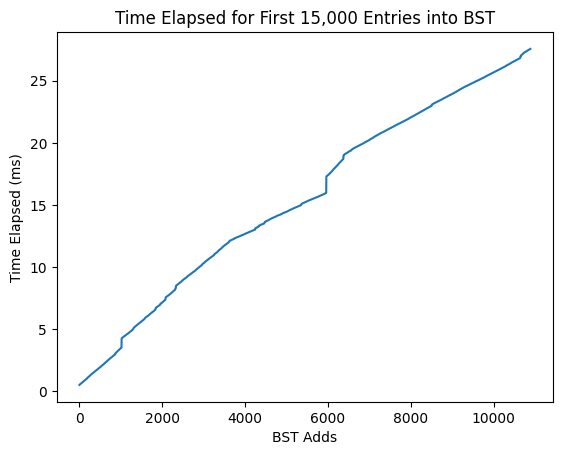

In [31]:
#Q6
def add_loans_with_timing(bank, bst, max_loans=15000):
    times = []
    start_time = time.time()
    
    for i, loan in enumerate(bank.loan_list[:max_loans]):
        if loan.interest_rate == -1:
            continue  # Skip loans with missing interest rates (-1)
        bst.add(loan.interest_rate, loan)
        elapsed_time = time.time() - start_time
        times.append(elapsed_time * 1000)  # Convert to milliseconds
    
    return times

# Measure time for adding first 15,000 loans
times = add_loans_with_timing(lcu, lcu_tree, 15000)

# Plot the time taken
plt.plot(range(1, len(times) + 1), times)
plt.xlabel('BST Adds')
plt.ylabel('Time Elapsed (ms)')
plt.title('Time Elapsed for First 15,000 Entries into BST')
plt.show()

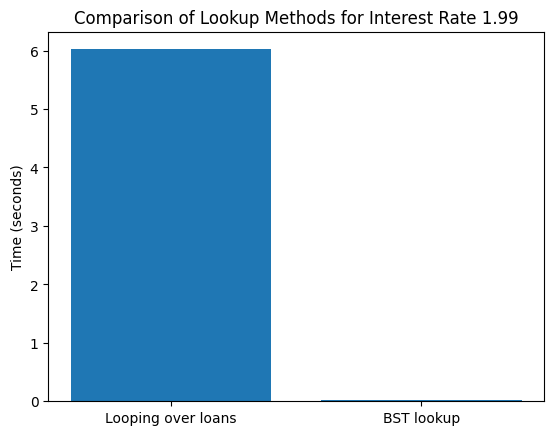

In [32]:
#Q7
def count_loans_by_rate_loop(bank, rate):
    start_time = time.time()
    count = sum(1 for loan in bank.loan_list if loan.interest_rate == rate)
    elapsed_time = time.time() - start_time
    return count, float(elapsed_time*1000)

# Method 2: Using BST lookup
def count_loans_by_rate_bst(bst, rate):
    start_time = time.time()
    loans = bst[rate]  # Assuming the __getitem__ method is implemented in BST
    count = len(loans)
    elapsed_time = time.time() - start_time
    return count, float(elapsed_time*1000)

# Measure the times
count_loop, time_loop = count_loans_by_rate_loop(lcu, 1.99)
count_bst, time_bst = count_loans_by_rate_bst(lcu_tree, 1.99)

# Plot the results
plt.bar(['Looping over loans', 'BST lookup'], [time_loop, time_bst])
plt.ylabel('Time (seconds)')
plt.title('Comparison of Lookup Methods for Interest Rate 1.99')
plt.show()

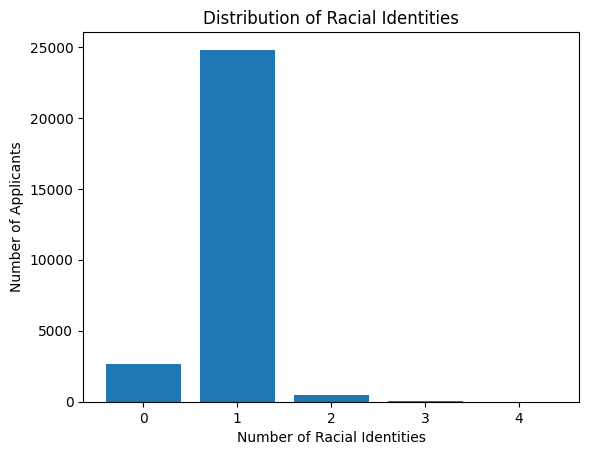

In [33]:
#Q8
def racial_identity_distribution(bank):
    race_count_dist = defaultdict(int)
    for loan in bank.loan_list:
        for applicant in loan.applicants:
            race_count_dist[len(applicant.race)] += 1
    return dict(race_count_dist)

# Get the distribution
race_dist = racial_identity_distribution(lcu)

# Plot the distribution
plt.bar(race_dist.keys(), race_dist.values())
plt.xlabel('Number of Racial Identities')
plt.ylabel('Number of Applicants')
plt.title('Distribution of Racial Identities')
plt.show()

In [36]:
#Q9
def count_leaf_nodes(node):
    # If the node is None, it's not a leaf node.
    if node is None:
        return 0
    # Check if it's a proper leaf node: no left and no right child.
    if node.left is None and node.right is None:
        print(f"Leaf Node: {node.key}")  # Print each leaf node for debugging.
        return 1

    # Otherwise, count leaf nodes in the left and right subtrees recursively.
    return count_leaf_nodes(node.left) + count_leaf_nodes(node.right)

leaf_count = count_leaf_nodes(lcu_tree.root)
leaf_count

Leaf Node: 2.469
Leaf Node: 2.531
Leaf Node: 2.594
Leaf Node: 2.656
Leaf Node: 2.719
Leaf Node: 2.762
Leaf Node: 2.844
Leaf Node: 2.938
Leaf Node: 3.063
Leaf Node: 3.156
Leaf Node: 3.219
Leaf Node: 3.251
Leaf Node: 3.319
Leaf Node: 3.376
Leaf Node: 3.437
Leaf Node: 3.49
Leaf Node: 3.501
Leaf Node: 3.532
Leaf Node: 3.594
Leaf Node: 3.626
Leaf Node: 3.687
Leaf Node: 3.719
Leaf Node: 3.781
Leaf Node: 3.812
Leaf Node: 3.843
Leaf Node: 3.876
Leaf Node: 3.906
Leaf Node: 3.937
Leaf Node: 3.969
Leaf Node: 4.001
Leaf Node: 4.062
Leaf Node: 4.08
Leaf Node: 4.126
Leaf Node: 4.156
Leaf Node: 4.219
Leaf Node: 4.282
Leaf Node: 4.312
Leaf Node: 4.375
Leaf Node: 4.437
Leaf Node: 4.468
Leaf Node: 4.562
Leaf Node: 4.687
Leaf Node: 4.781
Leaf Node: 4.843
Leaf Node: 4.938
Leaf Node: 5.001
Leaf Node: 5.032
Leaf Node: 5.126
Leaf Node: 5.187
Leaf Node: 5.312
Leaf Node: 5.5
Leaf Node: 5.562
Leaf Node: 5.751
Leaf Node: 6.04
Leaf Node: 6.49
Leaf Node: 6.99
Leaf Node: 7.15
Leaf Node: 7.85
Leaf Node: 8.5
Leaf Nod

61

In [35]:
#Q10
def find_top_n_keys(node, n, keys=[]):
    # Base case: if node is None or we already have n keys
    if node is None or len(keys) >= n:
        return keys

    # Traverse right subtree first (larger values)
    find_top_n_keys(node.right, n, keys)

    # If we haven't found enough keys, add the current node's key
    if len(keys) < n:
        keys.append(node.key)

    # Then traverse left subtree
    find_top_n_keys(node.left, n, keys)
    
    return keys

# Find the top 3 interest rates
top_3_rates = find_top_n_keys(lcu_tree.root, 3)
top_3_rates[-1]

9.85